# Example 7: World Population Cartogram
Deform a world map so that each country's area is proportional to its
population density.

This notebook demonstrates all three supported 2-D geographic file formats:
- **GeoJSON** — world country boundaries (`read_geojson`)
- **Shapefile** — same boundaries in .shp format (`read_shapefile`)
- **GeoTIFF** — gridded population density raster
  (`density_from_geotiff`, `read_geotiff`)

**Requires:** `pip install pyVDERM[2D]`  (adds geopandas and rasterio)

In [1]:
import pyVDERM as vd
import numpy as np
import matplotlib.pyplot as plt

## 1. Load map boundary from GeoJSON

`read_geojson` extracts the exterior ring vertices from every polygon feature
in the file.  The returned point array represents all country outlines as a
flat set of (longitude, latitude) coordinates.

Loaded 99,412 boundary points  (CRS: EPSG:4326)


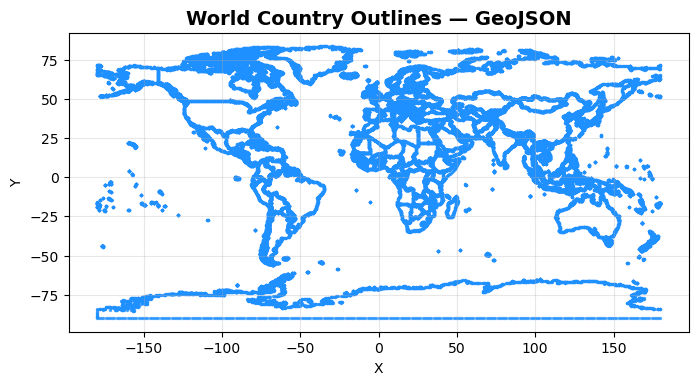

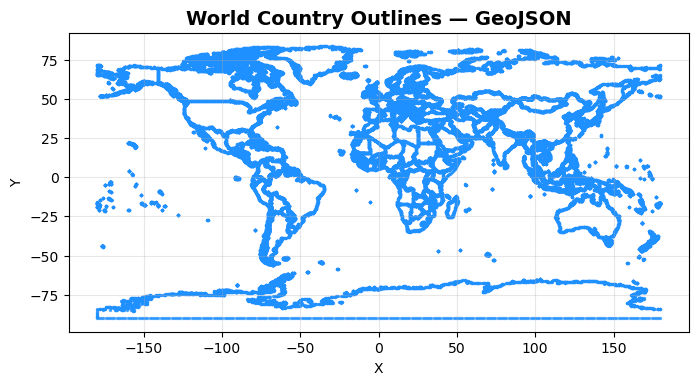

In [2]:
pts_json, crs = vd.read_geojson('ne_50m_admin_0_countries.json')
print(f"Loaded {len(pts_json):,} boundary points  (CRS: {crs})")
vd.plot_map_2d(pts_json, title='World Country Outlines — GeoJSON')

## 2. Create the underlying grid

The world map spans ≈360° × ≈180°.  `max_points=16384` gives a reasonable
balance between resolution and runtime.  Increase to 65536 for
publication-quality output at the cost of a longer deformation.

In [3]:
grid_params = vd.make_initial_grid_2d(pts_json, max_points=16384)
vd.print_grid_info_2d(grid_params)

2D GRID INFORMATION

Grid dimensions : 184 × 89 = 16,376 points
Grid spacing (h): 3.934426

Grid size  : [720.0000, 346.2295]
Object size: [360.0000, 173.5985]
Ratio      : [2.00x, 1.99x]

Grid bounds:
  x: [-360.0000, 360.0000]
  y: [-176.3144, 169.9151]

Object bounds:
  x: [-180.0000, 180.0000]
  y: [-89.9989, 83.5996]

Object margins:
  x: min=180.0000, max=180.0000
  y: min=86.3155, max=86.3155


## 3. Set population density from GeoTIFF

`density_from_geotiff` bilinearly interpolates the raster onto every grid node
and normalises the field so `mean(ρ) = 1`.

- `nodata_fill=1.0` gives ocean / missing-data cells neutral weight so they
  do not drive the deformation.
- Clipping to a minimum of 0.01 prevents division-by-zero in the advection
  step for any truly empty cells.

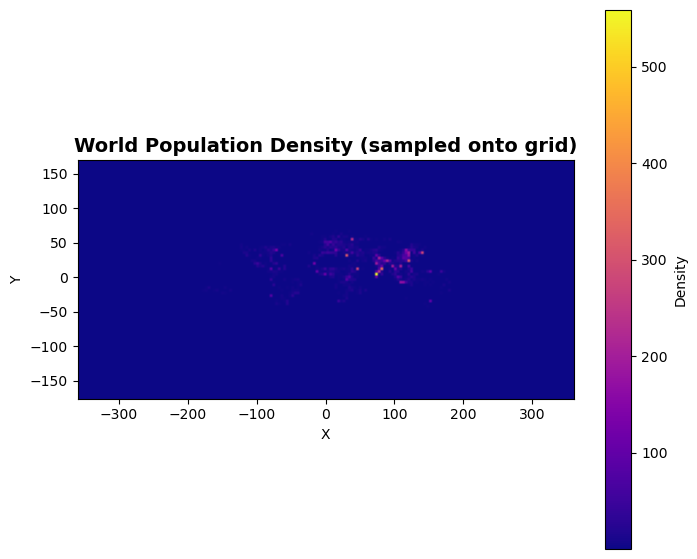

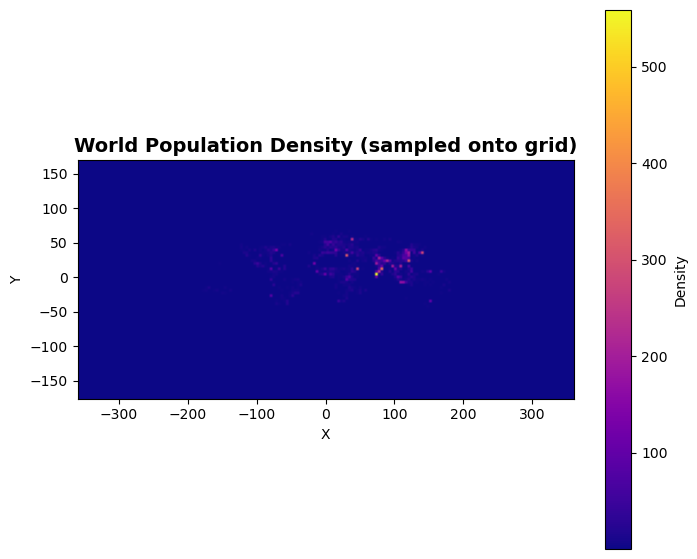

In [4]:
grid = vd.VDERMGrid2D(
    shape=grid_params['shape'],
    h=grid_params['h'],
    min_bounds=grid_params['min_bounds'],
)
vd.density_from_geotiff(
    grid,
    'gpw_v4_population_density_rev11_2020_1_deg.tif',
    nodata_fill=1.0,
    normalize=True,
)
grid.rho = np.maximum(grid.rho, 0.01)  # guard against near-zero density

vd.plot_density_field_2d(grid, title='World Population Density (sampled onto grid)')

## 4. Run the cartogram deformation

`run_VDERM` works unchanged with `VDERMGrid2D`.  The algorithm will converge
once the relative density variation drops below ε = 0.01.

In [13]:
deformed_grid = vd.run_VDERM(grid, n_max=5000)

Deforming: 100%|██████████| 5000/5000 [00:16<00:00, 308.09it/s, ε=3.109e-02, target=1.000e-02]


## 5. Apply deformation to the GeoJSON boundary points

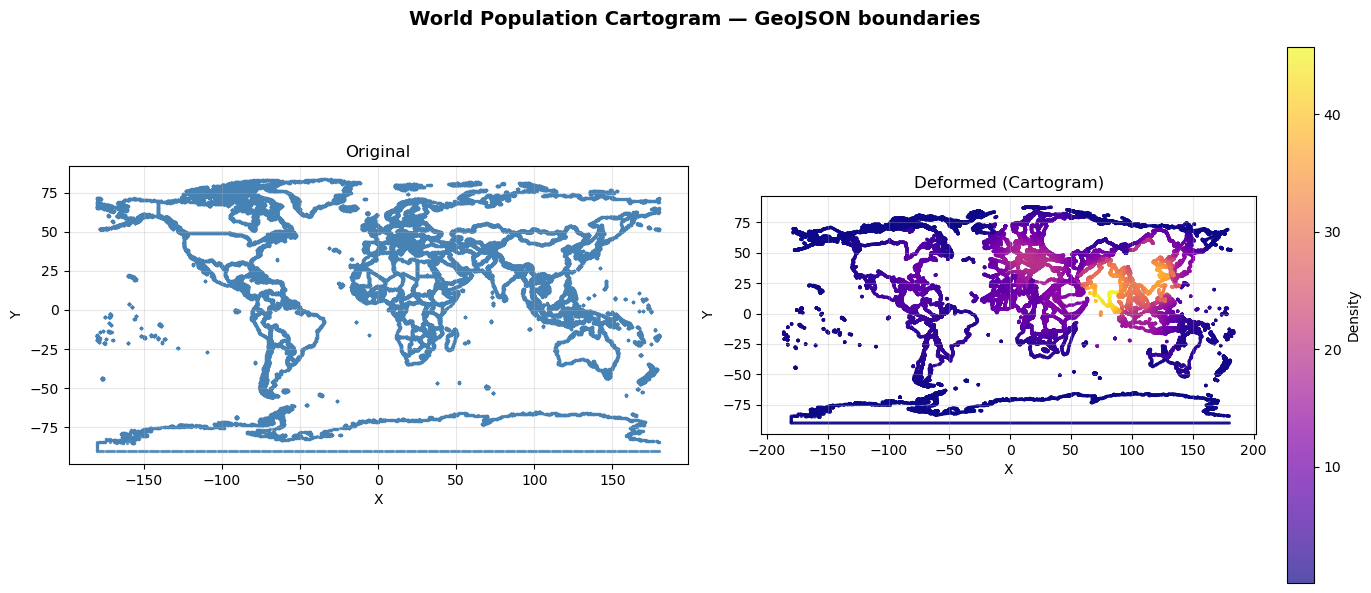

In [14]:
displacement  = deformed_grid.get_displacement_field()
deformed_json = vd.interpolate_to_map_2d(pts_json, grid_params, displacement)
dens_json     = vd.interpolate_densities_2d(pts_json, deformed_grid)

fig = vd.plot_map_before_after(
    pts_json, deformed_json,
    densities=dens_json,
    title='World Population Cartogram — GeoJSON boundaries',
)

## 6. Shapefile as an alternative boundary source

`read_shapefile` extracts boundary vertices from a .shp file.  If the .shx
index file is missing it is reconstructed automatically via GDAL's
`SHAPE_RESTORE_SHX` option.

Because the map boundary points are interchangeable, we can apply the **same**
displacement field computed above to the Shapefile points — no need to re-run
the deformation.

Loaded 99,432 boundary points from Shapefile  (CRS: None)


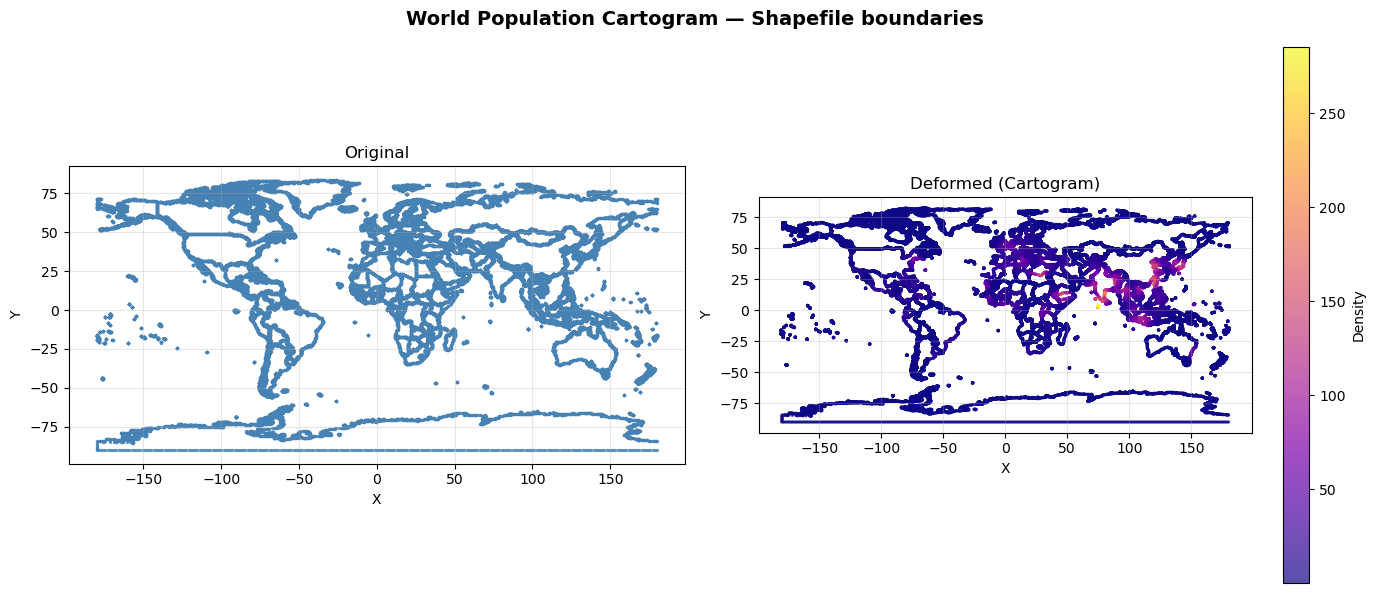

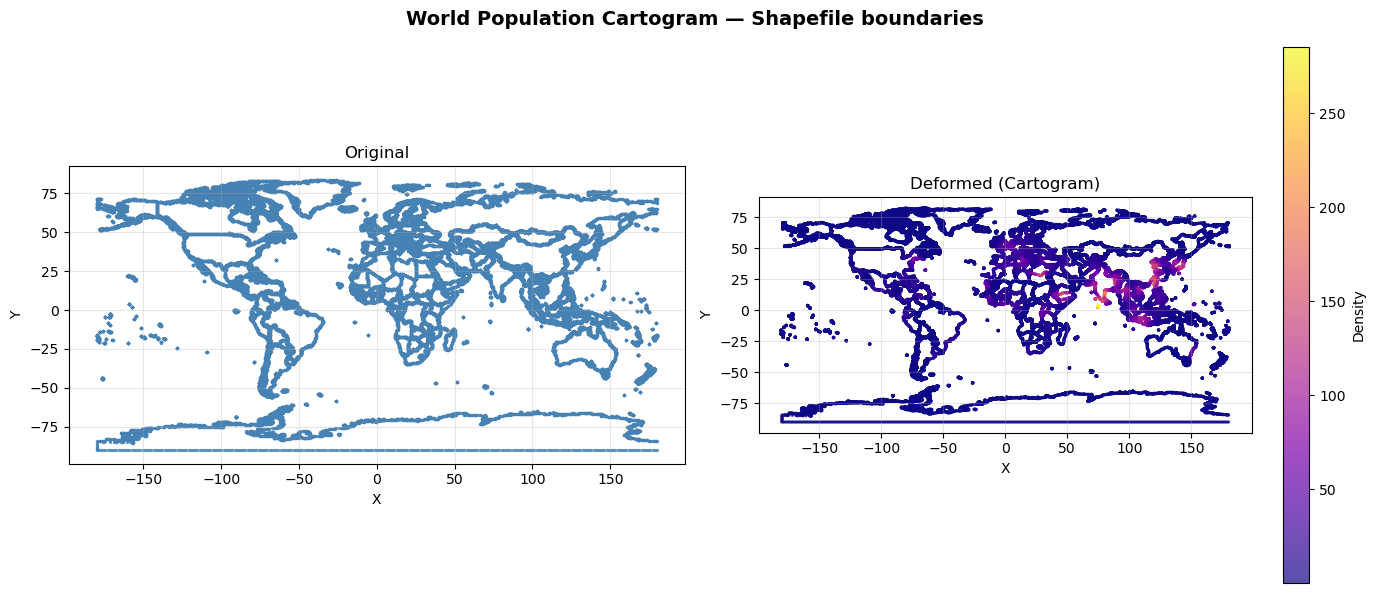

In [9]:
pts_shp, crs_shp = vd.read_shapefile('ne_50m_admin_0_countries.shp')
print(f"Loaded {len(pts_shp):,} boundary points from Shapefile  (CRS: {crs_shp})")

deformed_shp = vd.interpolate_to_map_2d(pts_shp, grid_params, displacement)
dens_shp     = vd.interpolate_densities_2d(pts_shp, deformed_grid)

vd.plot_map_before_after(
    pts_shp, deformed_shp,
    densities=dens_shp,
    title='World Population Cartogram — Shapefile boundaries',
)

## 7. Direct GeoTIFF reading

`read_geotiff` returns the raw raster array and coordinate vectors, giving full
control over preprocessing.  Here we visualise the population density data
on a log scale to reveal structure across several orders of magnitude.

In [10]:
data, x_coords, y_coords, crs_tif = vd.read_geotiff(
    'gpw_v4_population_density_rev11_2020_1_deg.tif'
)
print(f"Raster shape  : {data.shape}  (H × W)")
print(f"Longitude range: [{x_coords.min():.1f}, {x_coords.max():.1f}]")
print(f"Latitude range : [{y_coords.min():.1f}, {y_coords.max():.1f}]")
print(f"Value range    : [{np.nanmin(data):.1f}, {np.nanmax(data):.1f}]  ppl/km²")

Raster shape  : (180, 360)  (H × W)
Longitude range: [-179.5, 179.5]
Latitude range : [-89.5, 89.5]
Value range    : [0.0, 13639.6]  ppl/km²


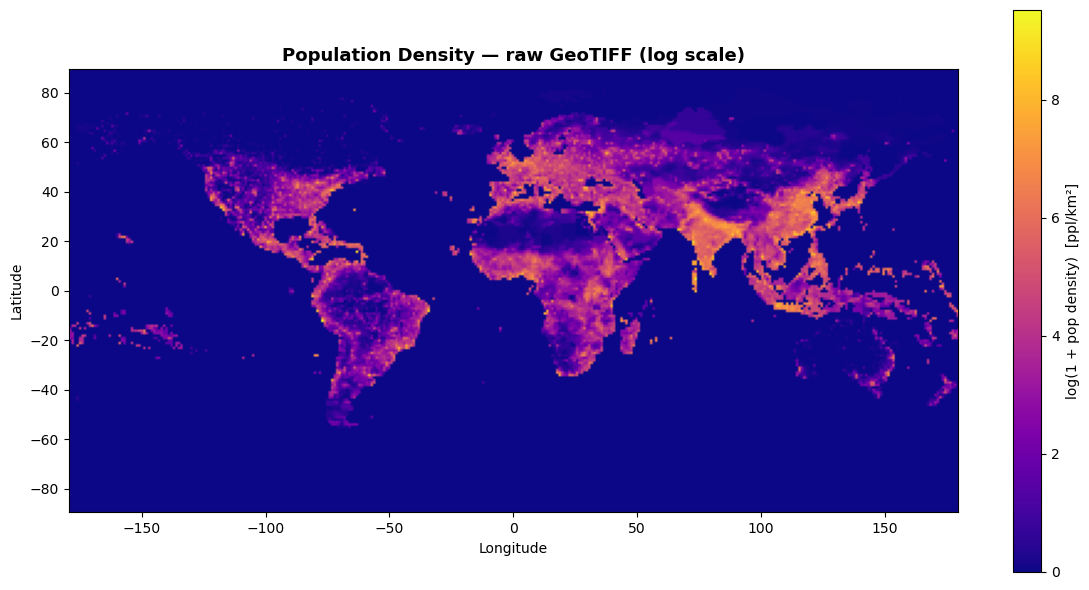

In [11]:
# Display on log scale to show both dense cities and sparse regions
log_data = np.log1p(np.where(np.isnan(data), 0.0, data))
origin   = 'upper' if y_coords[0] > y_coords[-1] else 'lower'

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(
    log_data,
    extent=[x_coords.min(), x_coords.max(), y_coords.min(), y_coords.max()],
    origin=origin,
    cmap='plasma',
    aspect='equal',
)
plt.colorbar(im, ax=ax, label='log(1 + pop density)  [ppl/km²]')
ax.set_title('Population Density — raw GeoTIFF (log scale)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

## 8. Export the cartogram

Save both the GeoJSON-based and Shapefile-based deformed point sets.

In [ ]:
vd.write_csv_2d('world_cartogram_geojson.csv', deformed_json, densities=dens_json)
print("Saved: world_cartogram_geojson.csv  (columns: x  y  rho)")

vd.write_csv_2d('world_cartogram_shapefile.csv', deformed_shp, densities=dens_shp)
print("Saved: world_cartogram_shapefile.csv  (columns: x  y  rho)")